## 2.1: Spans

A concept closely related to linear combinations is span. The **span** of vectors $\vec v_1,\ldots,\vec v_n$ is simply the set of all linear combinations of $\vec v_1,\ldots,\vec v_n$. We denote the span by
$$ \langle \vec v_1 ,\ldots, \vec v_n\rangle.$$
Note that in set-builder notation, the span can be written as
$$ \langle \vec v_1 ,\ldots, \vec v_n\rangle = \left\{ a_1 \vec v_1 + \cdots + a_n \vec v_n: a_1, \ldots, a_n \in \mathbb{R}\right\}.$$
For instance, we have seen that $\mathbb{R}^n$ is the span of the standard basis vectors $\vec e_1, \ldots \vec e_n$, hence allowing us to write $\mathbb{R}^n = \langle \vec e_1, \ldots, \vec e_n\rangle$.

## Lines and planes as spans

For now we will focus on spans of vectors in $\mathbb{R}^2$ and $\mathbb{R}^3$. If $\mathbb{R}^3$ is the span of the standard basis vectors $\vec e_1, \vec e_2, \vec e_3$, what is the span of just $\vec e_1, \vec e_2$? We obtain vectors of the following form:
$$ a\vec e_1 + b\vec e_2 = a \begin{bmatrix} 1\\0\\0 \end{bmatrix} + b \begin{bmatrix} 0\\1\\0 \end{bmatrix} = \begin{bmatrix} a\\b\\0 \end{bmatrix}$$
for all scalars $a,b$. In other words, we obtain all vectors with the third entry being zero.

Geometrically, the span corresponds to the $x$-$y$ plane inside the three-dimensional Euclidean space depicted in blue:

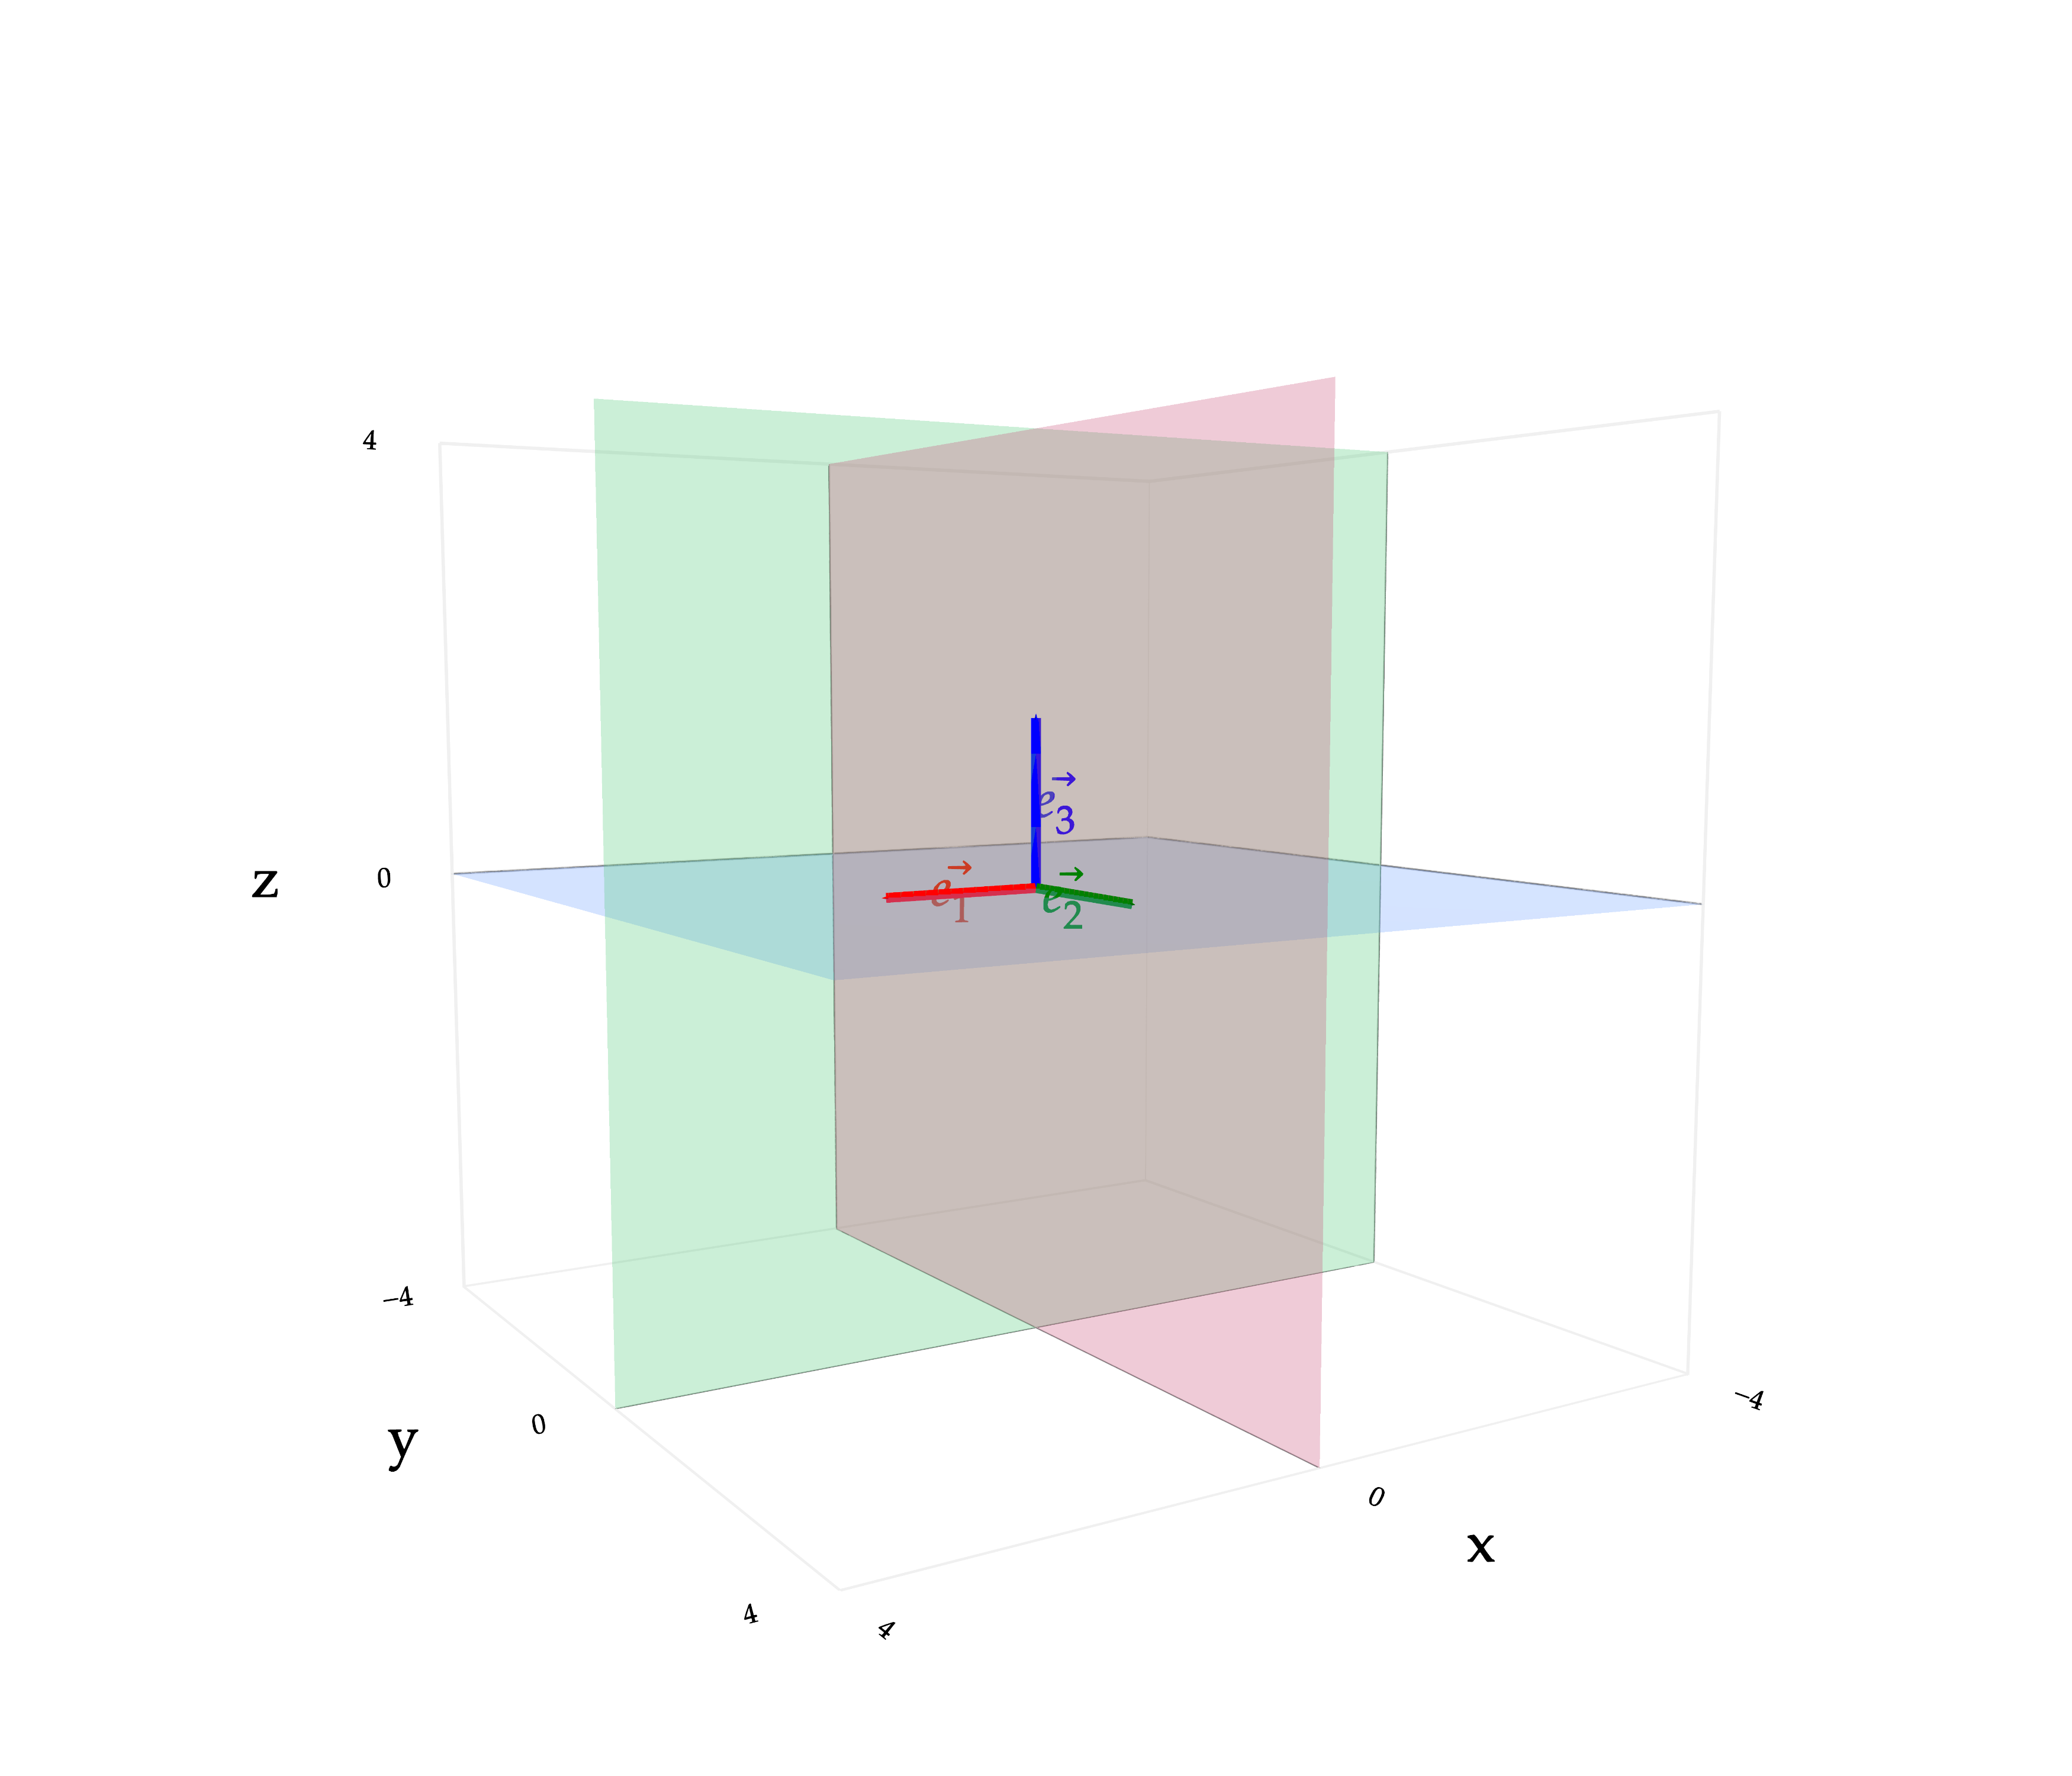

In [3]:
from IPython.display import display, HTML
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# 1. Define the standard basis vectors to orient the viewer
vectors = [
    (((0, 0, 0), (1.5, 0, 0)), 'red', '<i>e</i><sub>1</sub>\u20D7'),
    (((0, 0, 0), (0, 1.5, 0)), 'green', '<i>e</i><sub>2</sub>\u20D7'),
    (((0, 0, 0), (0, 0, 1.5)), 'blue', '<i>e</i><sub>3</sub>\u20D7')
]

# Create the base figure with the vectors
fig = plot_vectors_non_origin(vectors, vdeltax=0.4, vdeltay=0.4, vdeltaz=0.4)

# 2. Define the grid boundaries for the planes
# We only need the extreme corners (2 points per axis) to draw a flat square
x_vals = np.array([-4, 4])
y_vals = np.array([-4, 4])
z_vals = np.array([-4, 4])

# --- XY Plane (z=0) - Blue tint ---
x_xy, y_xy = np.meshgrid(x_vals, y_vals)
z_xy = np.zeros_like(x_xy)
fig.add_trace(go.Surface(
    x=x_xy, y=y_xy, z=z_xy, 
    colorscale=[[0, 'rgba(100, 150, 250, 0.3)'], [1, 'rgba(100, 150, 250, 0.3)']],
    showscale=False, hoverinfo='skip'
))

# --- XZ Plane (y=0) - Red tint ---
x_xz, z_xz = np.meshgrid(x_vals, z_vals)
y_xz = np.zeros_like(x_xz)
fig.add_trace(go.Surface(
    x=x_xz, y=y_xz, z=z_xz,
    colorscale=[[0, 'rgba(100, 250, 150, 0.3)'], [1, 'rgba(100, 250, 150, 0.3)']],
    
    showscale=False, hoverinfo='skip'
))

# --- YZ Plane (x=0) - Green tint ---
y_yz, z_yz = np.meshgrid(y_vals, z_vals)
x_yz = np.zeros_like(y_yz)
fig.add_trace(go.Surface(
    x=x_yz, y=y_yz, z=z_yz, 
    colorscale=[[0, 'rgba(250, 100, 150, 0.3)'], [1, 'rgba(250, 100, 150, 0.3)']],
    showscale=False, hoverinfo='skip'
))

# 3. Format the layout for a clean schematic look
# Using tickvals limits the labels to just the outer edges and origin
schematic_ticks = [-4, 0, 4]

fig.update_layout(
    width=700, 
    height=600,
    scene=dict(
        xaxis=dict(range=[-4, 4], tickvals=schematic_ticks),
        yaxis=dict(range=[-4, 4], tickvals=schematic_ticks),
        zaxis=dict(range=[-4, 4], tickvals=schematic_ticks),
        aspectratio=dict(x=1, y=1, z=1) # Perfectly cubic
    )
)

fig.show(scale=5)

We can similarly work out that
* the span of $\vec e_2, \vec e_3$ form the $y$-$z$ plane colored in red;
* the span of $\vec e_1, \vec e_3$ form the $x$-$z$ plane colored in green.

We can also think about spans of vectors other than the standard basis vectors. Let's start with the simplest case where we only have one vector. What is the span of the vector $\vec v = \begin{bmatrix}1 \\ 2\end{bmatrix}$? It is the set of all multiples of $\vec v$, which in the Euclidean plane corresponds to the following line through the origin:

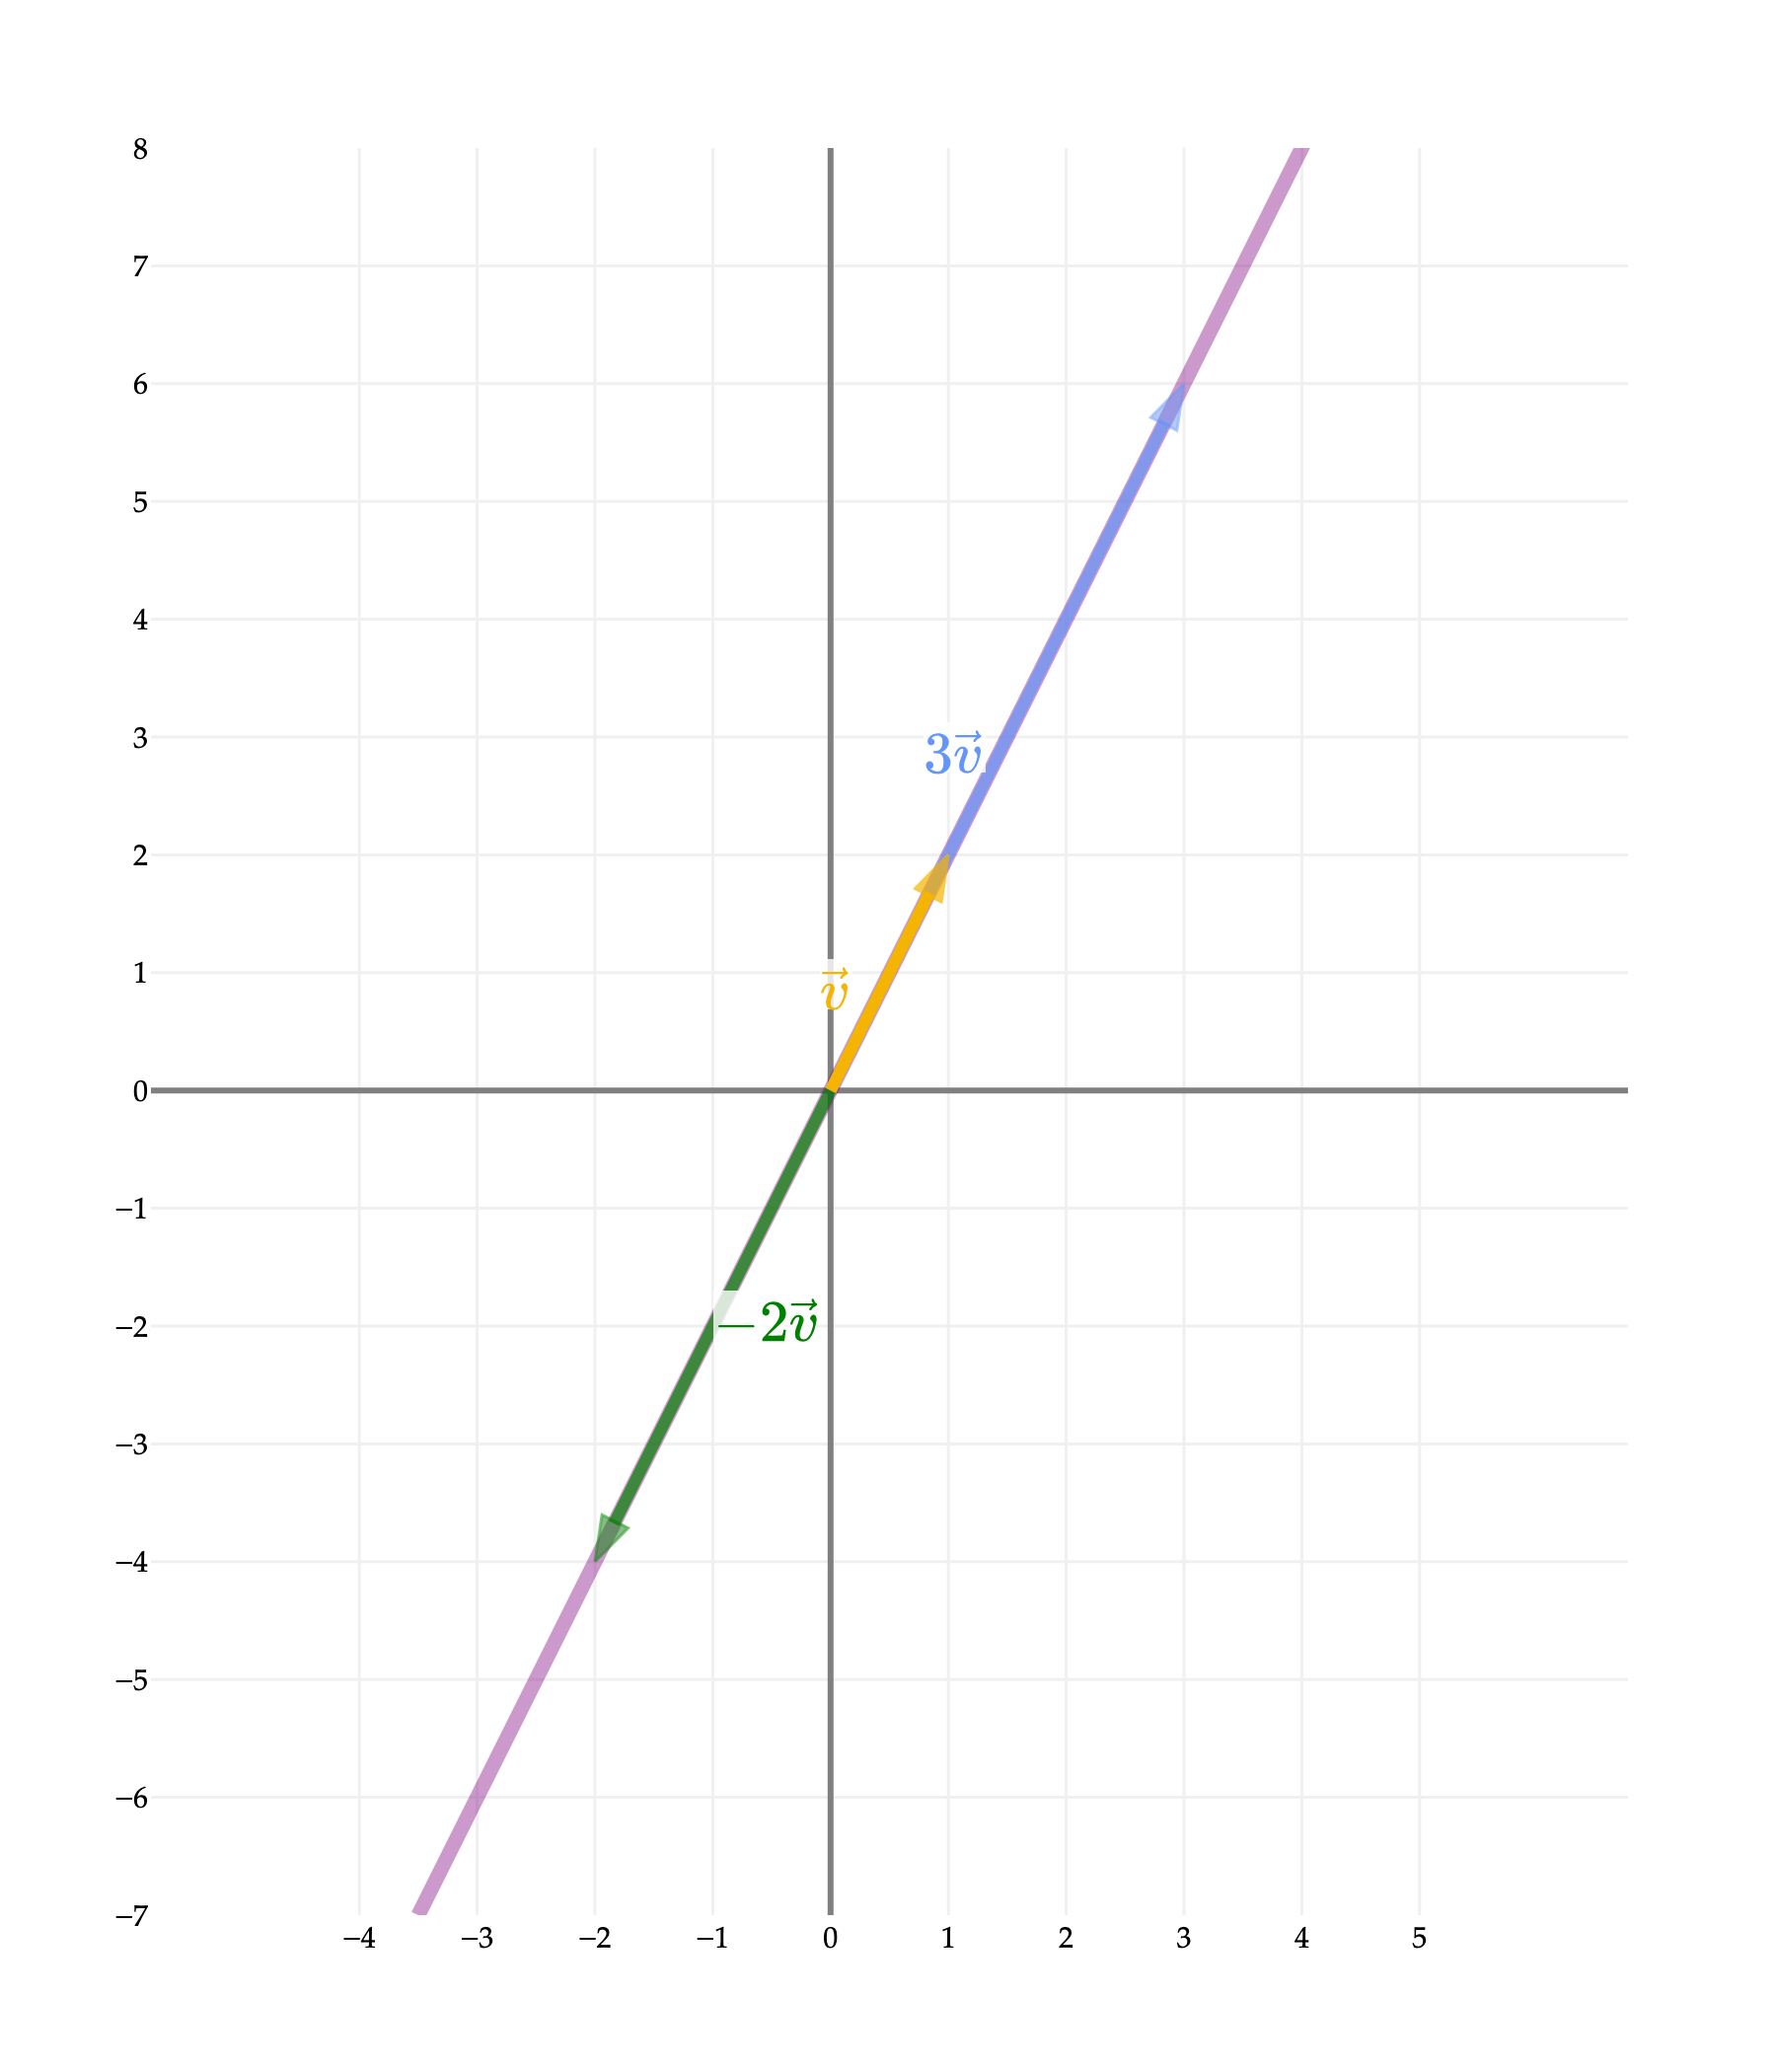

In [4]:
from IPython.display import display, HTML
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors

# 1. Define the vectors
vectors = [
    ((3, 6), 'rgba(100, 150, 250, 0.7)', r'$3\vec{v}$'),       
    ((-2, -4), 'rgba(0, 128, 0, 0.7)', r'$-2\vec{v}$'),        
    ((1, 2), '#f4b400', r'$\vec{v}$')                          
]

# Create the figure with the vectors
fig = plot_vectors(vectors, vdeltax=0.5, vdeltay=-0.2)

# 2. Add the continuous solid line representing the span
# We make it thick (width=8) but highly transparent (opacity=0.2)
fig.add_trace(go.Scatter(
    x=[-3.5, 4.5],
    y=[-7, 9],
    mode='lines',
    line=dict(color='rgba(128, 0, 128, 0.4)', width=5), 
    showlegend=False,
    hoverinfo='skip'
))

# 3. FIX THE CLUTTER (Z-Ordering)
# Plotly draws traces in the order they are added. The line was just added last (on top).
# This single line of Python tuple reassignment pushes the line to the absolute back.
fig.data = (fig.data[-1],) + fig.data[:-1]

# 4. Format the layout
fig.update_layout(width=600, height=700, yaxis_scaleanchor="x")
fig.update_xaxes(range=[-4, 5], tickvals=np.arange(-4, 6))
fig.update_yaxes(range=[-7, 8], tickvals=np.arange(-7, 9))

fig.show(scale=3)

Similarly, the span of a vector in $\mathbb{R}^3$ also traces out a line in three-dimensional Euclidean space. Here is an illustration for the vector $\vec v = \begin{bmatrix} 1\\1\\1\end{bmatrix}$ with some of its scalar multiples.

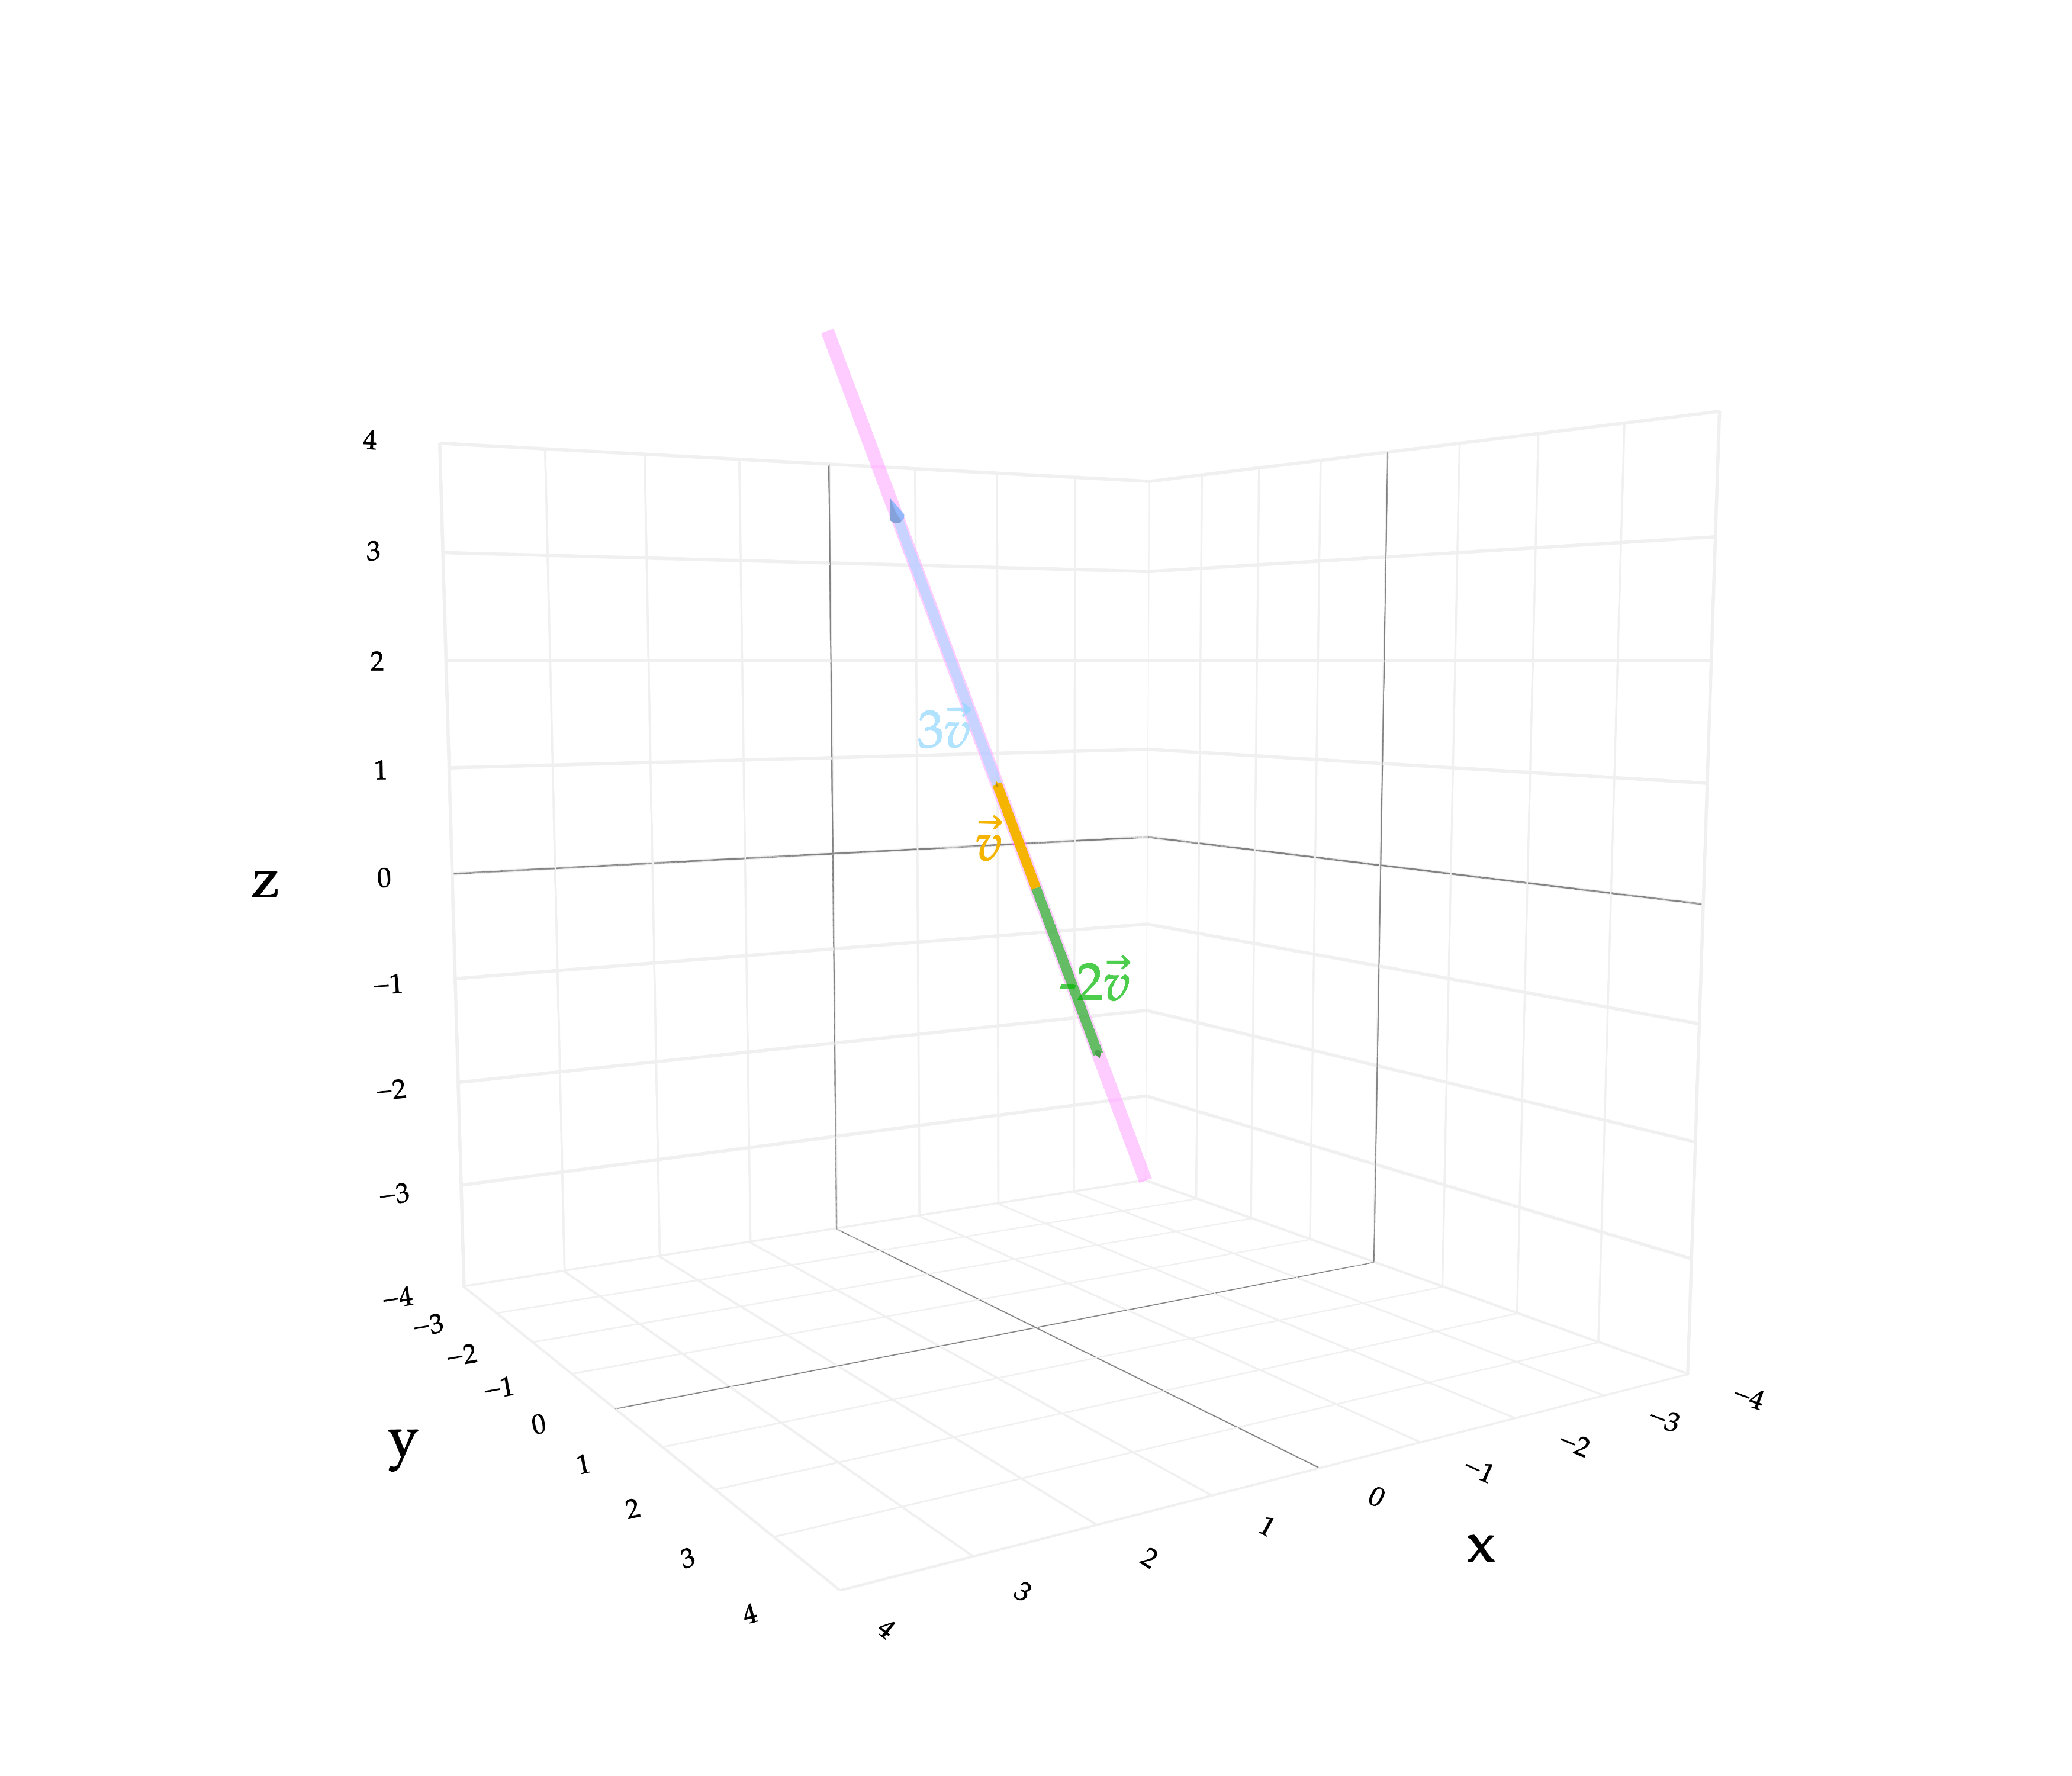

In [5]:
from IPython.display import display, HTML
import plotly.io as pio
import plotly.graph_objects as go
import numpy as np

# Set default renderer to high-DPI static image
pio.renderers.default = "png"
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

# ---
from utils import plot_vectors_non_origin

# 1. Define the 3D vectors
# Start/end coordinates: (((x0, y0, z0), (x1, y1, z1)), color, label)
vectors = [
    (((0, 0, 0), (3, 3, 3)), 'rgba(100, 150, 250, 0.7)', '3<i>v</i>\u20D7'),     # 3v (transparent blue)
    (((0, 0, 0), (-2, -2, -2)), 'rgba(0, 128, 0, 0.7)', '-2<i>v</i>\u20D7'),      # -2v (transparent green)
    (((0, 0, 0), (1, 1, 1)), '#f4b400', '<i>v</i>\u20D7')                         # The original vector v (solid gold)
]

# Create the figure
fig = plot_vectors_non_origin(vectors, vdeltax=0.5, vdeltay=0.5, vdeltaz=0.5)

# 2. Add the continuous solid line representing the span in 3D
# The line represents the parametric equation x=t, y=t, z=t
# Thick (width=8) but highly transparent (opacity=0.2) purple line
fig.add_trace(go.Scatter3d(
    x=[-4, 4],
    y=[-4, 4],
    z=[-4, 4],
    mode='lines',
    line=dict(color='rgba(128, 0, 128, 0.2)', width=8), 
    showlegend=False,
    hoverinfo='skip'
))

# 3. FIX THE CLUTTER (Z-Ordering)
# Push the line to the absolute back so it rests beneath the 3D arrows
fig.data = (fig.data[-1],) + fig.data[:-1]

# 4. Format the layout
# Frame the grid cleanly with integer ticks (dtick=1)
fig.update_layout(
    width=700, 
    height=600,
    scene=dict(
        xaxis=dict(range=[-4, 4], dtick=1),
        yaxis=dict(range=[-4, 4], dtick=1),
        zaxis=dict(range=[-4, 4], dtick=1),
        aspectratio=dict(x=1, y=1, z=1) # Keeps the 3D space perfectly cubic
    )
)

fig.show(scale=5)

The upshot is that lines and planes through the origin in our usual two/three-dimensional space cna be thought of as spans of vectors. We will explore this concept in more detail in the next subsections.

<!-- The upshot is that geometric objects such as lines and planes in 2D/3D Euclidean space can be viewed as spans of vectors. A good slogan to have in mind is -->
<!-- $$ \text{``The span of one vector form a line; the span of two vectors form a plane.''}$$ -->
<!-- One must be careful with the slogan, since two vectors do not always form a plane. We -->